# Customer Segmentation (Clustering) 

In this notebook, we will:
1. Preprocess our RFM features (Log Transformation & Scaling).
2. Apply **K-Means** clustering and find the optimal number of clusters using both **Inertia (Elbow Method)** and the **Silhouette Score**.
3. Apply **DBSCAN** clustering to identify core groups and outliers.
4. Evaluate the clusters and provide **Business Interpretations**.

In [75]:
# Loading libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## 1. Load Data & Preprocessing
Distance-based clustering algorithms (like K-Means and DBSCAN) require data to be symmetrically distributed and on the same scale.

In [76]:
# RFM features
try:
    rfm = pd.read_csv('../data/processed/rfm_features.csv')
    print(f"Successfully loaded {len(rfm)} customers.")
except FileNotFoundError:
    print("Error: Could not find rfm_features.csv. Did you run the second notebook?")

Successfully loaded 5878 customers.


In [77]:
rfm.set_index('CustomerID', inplace=True)

In [78]:
rfm

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40
...,...,...,...
18283.0,4,22,2664.90
18284.0,432,1,461.68
18285.0,661,1,427.00


In [79]:
# 1. Log Transformation to handle right-skewness
rfm_log = np.log(rfm + 0.1) # We add a small constant (0.1) to avoid log(0) issues

In [80]:
# 2. Standardization (Mean=0, Variance=1)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)
display(rfm_scaled.head())

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,0.845198,1.250061,3.200252
12347.0,-2.256472,0.847674,1.214707
12348.0,-0.057517,0.383845,0.573261
12349.0,-0.899216,0.165022,1.138729
12350.0,0.814270,-1.154083,-0.721432


## 2. K-Means Clustering
First, we evaluate different values of `K` (number of clusters) using two mathematical metrics:
1. **Inertia (Elbow Method)**: Measures the sum of squared distances of samples to their closest cluster center (lower is better).
2. **Silhouette Score**: Measures how similar an object is to its own cluster compared to other clusters (ranges from -1 to 1; higher is better).

**🔄 K-Means Step-by-Step:**

| Step | What happens | Centroids? |
|------|--------------|-------------|
| 1 | Initialize random centroids | Random starting positions |
| 2 | Assign points to nearest centroid | Fixed (for this step) |
| 3 | **Update centroids** → move to mean of assigned points | ✅ **Updated** |
| 4 | Repeat steps 2-3 until convergence | ✅ **Updated each time** |

> **📊 Silhouette Score** A metric that measures how well-separated the clusters are in clustering algorithms**

---

**Formula:** $\text{Silhouette Score} = \frac{b - a}{\max(a, b)}$

where:
- **a** = Mean distance to points in the SAME cluster (cohesion)
- **b** = Mean distance to points in the NEAREST other cluster (separation)

--- 

| Score Range | Meaning | Quality |
|-------------|---------|---------|
| **+1.0** | Perfectly separated clusters | ✅ Excellent |
| **0.0** | Overlapping clusters | ⚠️ Weak |
| **-1.0** | Wrong cluster assignment | ❌ Bad |

In [81]:
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(rfm_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, cluster_labels))

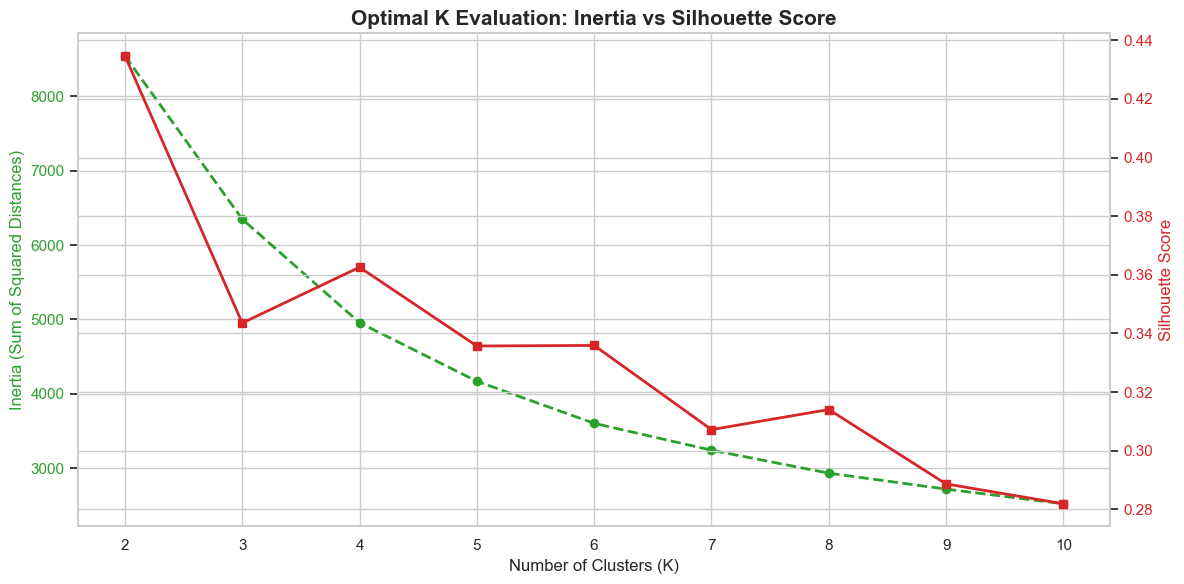

In [82]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Inertia (Elbow Method) 
color = 'tab:green'
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (Sum of Squared Distances)', color=color)
ax1.plot(k_range, inertia, marker='o', linestyle='--', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(k_range)

# For Silhouette Score
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)  
ax2.plot(k_range, silhouette_scores, marker='s', linestyle='-', color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Optimal K Evaluation: Inertia vs Silhouette Score', fontsize=15, fontweight='bold')
fig.tight_layout()  
plt.show()

### Fit K-Means: Justification for 8 Segments
**Mathematical Evaluation:**
Looking at the graph above, the "Elbow" for inertia happens around $K=4$. Similarly, the **Silhouette Score** peaks at $K=2$. From a strictly mathematical standpoint, the algorithm naturally wants to clump the data into 2 to 4 very broad groups.

**Business Justification (Why $K=8$):**
However, splitting a massive retail customer base into only 3 segments is **too broad for targeted marketing campaigns**. According to our project requirements, we need **6 to 8 segments**.

While the Silhouette Score drops as we increase $K$, the score at $K=8$ remains positive and stable (around ~0.30). It is not negative, which means the clusters are still mathematically coherent and valid. By forcing the algorithm into **$K=8$ distinct behavioral segments**, we trade a slightly lower Silhouette Score in exchange for a **highly granular, actionable view** of the customer base. This allows the marketing team to differentiate between a "Loyal Customer", a "Recent Small Buyer", a "Promising Newcomer", and a "Big Spender At Risk", which is impossible to do with only 3 mathematically-optimal clusters.

In [83]:
optimal_k = 8
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['KMeans_Cluster'] = kmeans.fit_predict(rfm_scaled)

In [84]:
rfm['KMeans_Cluster']

CustomerID
12346.0    1
12347.0    4
12348.0    5
12349.0    1
12350.0    2
          ..
18283.0    3
18284.0    2
18285.0    2
18286.0    0
18287.0    1
Name: KMeans_Cluster, Length: 5878, dtype: int32

In [85]:
# Evaluation with Silhouette 
sil_score = silhouette_score(rfm_scaled, rfm['KMeans_Cluster'])
print(f"Final K-Means Silhouette Score (K={optimal_k}): {sil_score:.3f}")

Final K-Means Silhouette Score (K=8): 0.314


In [86]:
if 'Segment_Name' not in rfm.columns:
    ordered_clusters = rfm.groupby('KMeans_Cluster')['Monetary'].mean().sort_values(ascending=False).index
    labels = [
        "Champions",
        "Loyal Customers",
        "Needs Attention",
        "At Risk",
        "Potential Loyalists",
        "Promising",
        "Recent/New Customers",
        "Hibernating / Lost"
    ]
    mapping = dict(zip(ordered_clusters, labels))
    rfm['Segment_Name'] = rfm['KMeans_Cluster'].map(mapping)
    display(rfm[['Recency', 'Frequency', 'Monetary', 'Segment_Name']].head(10))

,Recency,Frequency,Monetary,Segment_Name
CustomerID,,,,
12346.0,326,12,77556.46,Loyal Customers
12347.0,2,8,4921.53,At Risk
12348.0,75,5,2019.40,Needs Attention
12349.0,19,4,4428.69,Loyal Customers
12350.0,310,1,334.40,Hibernating / Lost
12351.0,375,1,300.93,Hibernating / Lost
12352.0,36,10,2849.84,Loyal Customers
12353.0,204,2,406.76,Promising
12354.0,232,1,1079.40,Promising


## 3. DBSCAN Clustering
Unlike K-Means, DBSCAN does not require us to specify the number of clusters. Instead, it groups densely packed points and marks sparse points as outliers (`-1`).

| Parameter | Meaning | 
|-----------|---------|
| `eps` | Maximum distance between two points to be considered neighbors | `0.5` |
| `min_samples` | Minimum number of points required to form a dense cluster | `15` |

In [87]:
dbscan = DBSCAN(eps=0.5, min_samples=15)
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

In [88]:
n_clusters = len(set(rfm['DBSCAN_Cluster'])) - (1 if -1 in rfm['DBSCAN_Cluster'] else 0)
n_noise = list(rfm['DBSCAN_Cluster']).count(-1)

print(f"DBSCAN found {n_clusters} clusters and {n_noise} noise points (outliers).")
display(rfm['DBSCAN_Cluster'].value_counts())

DBSCAN found 3 clusters and 103 noise points (outliers).


DBSCAN_Cluster
 0    4176
 1    1599
-1     103
Name: count, dtype: int64

*Note: DBSCAN often struggles with RFM customer data because human behavior exists on a continuous spectrum rather than distinct, separated dense islands. K-Means is much better suited for strict business segmentation.*

In [89]:
rfm['Log_Recency'] = np.log10(rfm['Recency'] + 1)
rfm['Log_Frequency'] = np.log10(rfm['Frequency'] + 1)
rfm['Log_Monetary'] = np.log10(rfm['Monetary'] + 1)

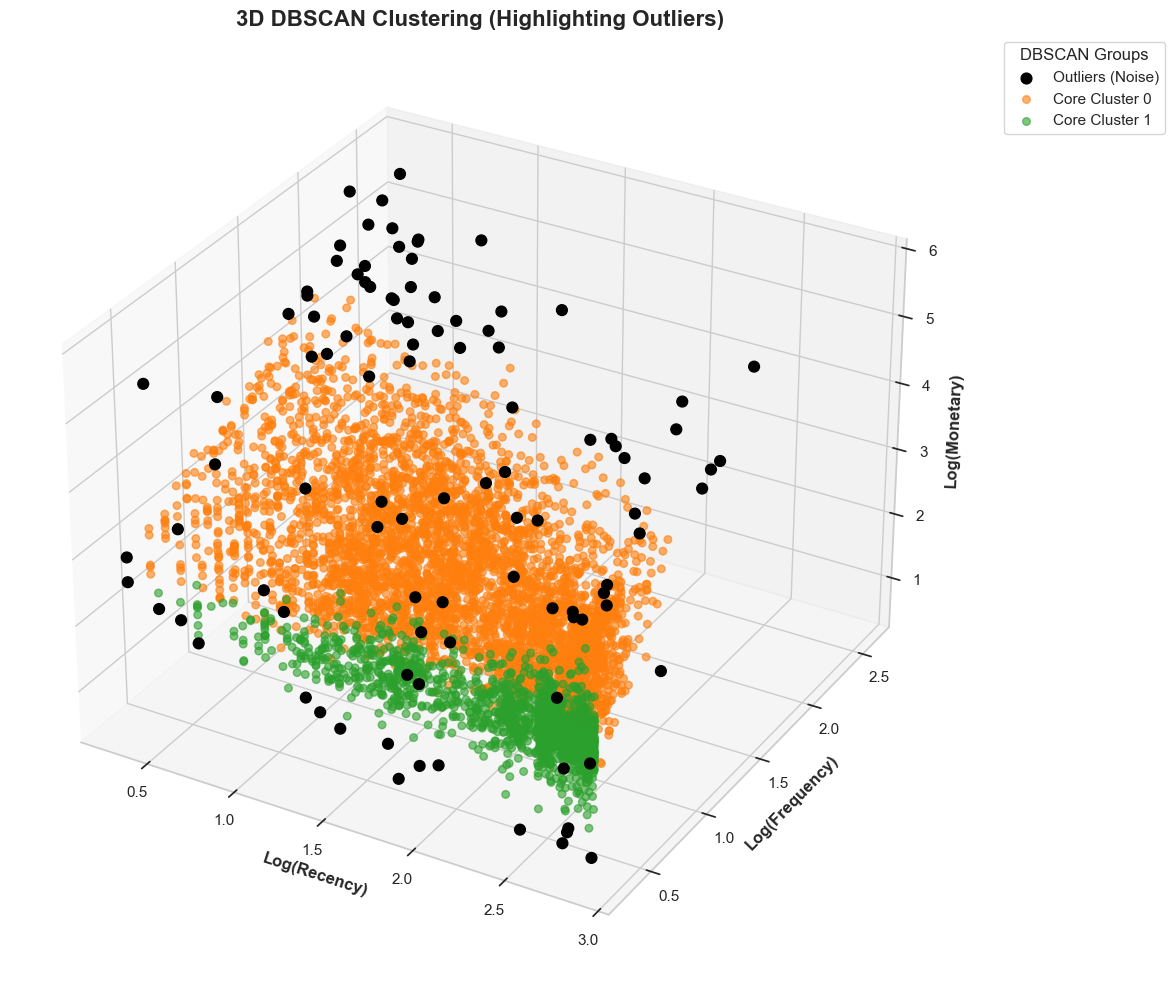

In [90]:
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

unique_clusters = sorted(list(rfm['DBSCAN_Cluster'].unique()))
colors = sns.color_palette("tab10", len(unique_clusters))
color_dict = dict(zip(unique_clusters, colors))
if -1 in color_dict:
    color_dict[-1] = (0.0, 0.0, 0.0) # Black

for cluster in unique_clusters:
    subset = rfm[rfm['DBSCAN_Cluster'] == cluster]
    label_name = 'Outliers (Noise)' if cluster == -1 else f'Core Cluster {cluster}'
    ax.scatter(subset['Log_Recency'], 
               subset['Log_Frequency'], 
               subset['Log_Monetary'], 
               c=[color_dict[cluster]],
               label=label_name, 
               alpha=0.6 if cluster != -1 else 1.0,
               s=30 if cluster != -1 else 60)

ax.set_xlabel('Log(Recency)', fontweight='bold')
ax.set_ylabel('Log(Frequency)', fontweight='bold')
ax.set_zlabel('Log(Monetary)', fontweight='bold')
ax.set_title('3D DBSCAN Clustering (Highlighting Outliers)', fontsize=16, fontweight='bold')

plt.legend(title='DBSCAN Groups', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Output:**

- 0, 1 : Normal points in clusters
- -1 : ❌ Outlier / Noise (doesn't fit anywhere)

## 4. Cluster Evaluation & Business Interpretation
Let's interpret the **8 K-Means** clusters by looking at the average Recency, Frequency, and Monetary value for each group.

In [91]:
# The mean RFM values for each K-Means cluster
cluster_summary = rfm.groupby('KMeans_Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

cluster_summary.columns = ['Avg Recency (Days)', 'Avg Frequency (Orders)', 'Avg Monetary (£)', 'Customer Count']
cluster_summary = cluster_summary.sort_values(by='Avg Monetary (£)', ascending=False)
display(cluster_summary)

,Avg Recency (Days),Avg Frequency (Orders),Avg Monetary (£),Customer Count
KMeans_Cluster,,,,
3,8.4,39.6,26307.6,308
1,44.9,12.4,5562.5,826
5,241.6,5.9,2416.9,747
4,5.5,6.3,1979.8,385
7,42.1,3.8,1107.4,843
0,353.7,2.3,724.9,1037
6,43.8,1.4,322.9,556
2,454.6,1.1,208.3,1176


### Business Segments Identified (Based on 8 Clusters):
*(By sorting our clusters by their average values, we can automatically assign descriptive marketing names to each group)*

1. **🏆 Champions**: Bought recently, buy very often, and spend the absolute most.
2. **⭐ Loyal Customers**: Spend good money and buy frequently, but maybe haven't bought in the last few days.
3. **📈 Potential Loyalists**: Recent customers who have spent a decent amount and bought more than once.
4. **👋 Recent/New Customers**: Bought very recently, but have only made 1 or 2 small purchases.
5. **🌱 Promising**: Recent shoppers, but haven't spent much money yet.
6. **⚠️ Needs Attention**: Have above-average spending and frequency, but haven't purchased in a while.
7. **🚨 At Risk**: Used to spend big money and purchase often, but haven't returned in a very long time.
8. **💤 Hibernating / Lost**: Lowest spenders, lowest frequency, and haven't purchased in the longest time.

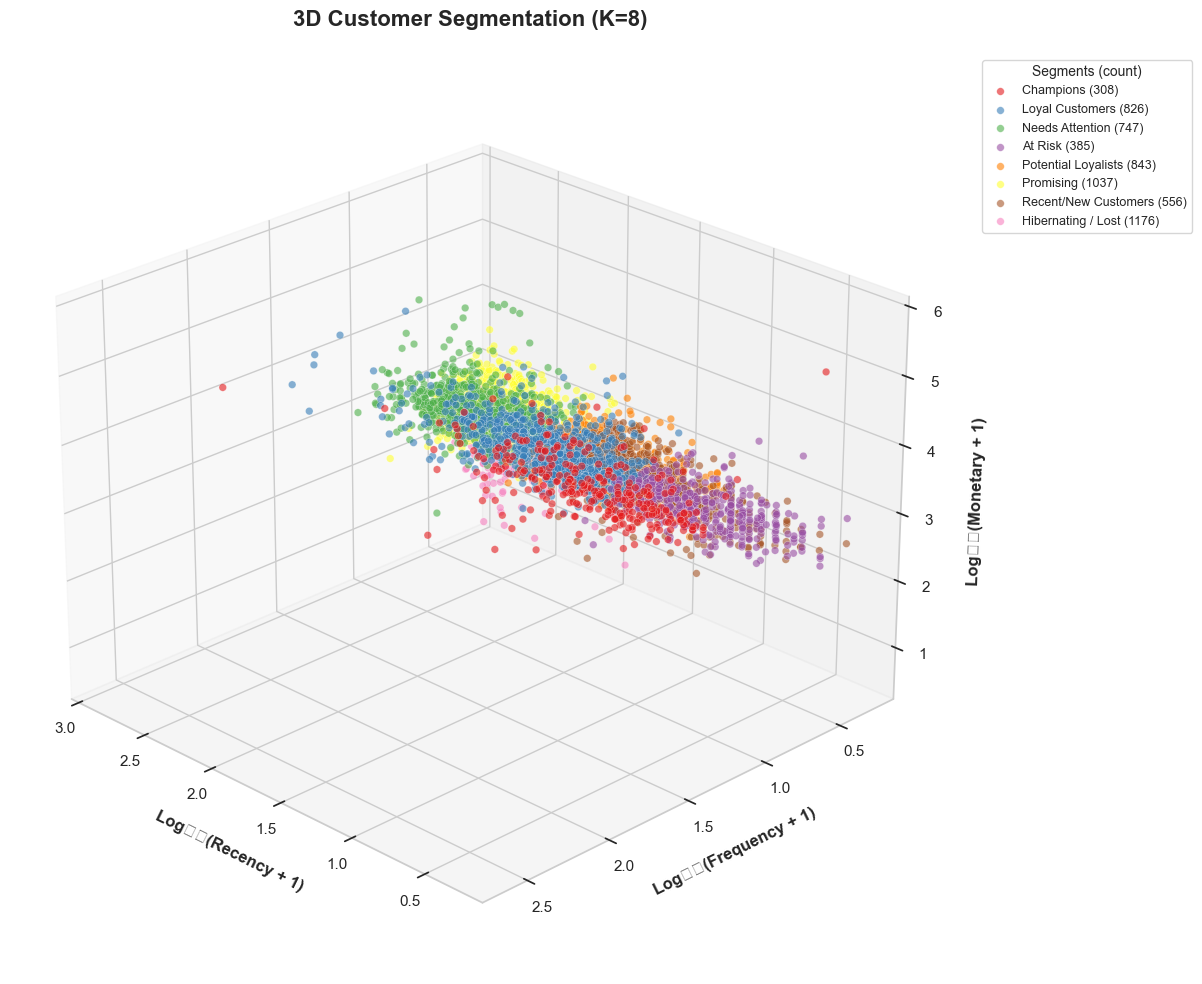

In [92]:
# --- 3D Customer Segmentation (K=8) ---

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

colors = sns.color_palette("Set1", len(labels))
color_dict = dict(zip(labels, colors))

for segment in labels:
    subset = rfm[rfm['Segment_Name'] == segment]
    ax.scatter(subset['Log_Recency'],
               subset['Log_Frequency'],
               subset['Log_Monetary'],
               c=[color_dict[segment]],
               label=f'{segment} ({len(subset)})',
               alpha=0.6,
               s=30,
               edgecolors='w',
               linewidth=0.3)

ax.set_xlabel('Log₁₀(Recency + 1)', fontweight='bold', labelpad=10)
ax.set_ylabel('Log₁₀(Frequency + 1)', fontweight='bold', labelpad=10)
ax.set_zlabel('Log₁₀(Monetary + 1)', fontweight='bold', labelpad=10)
ax.set_title('3D Customer Segmentation (K=8)', fontsize=16, fontweight='bold', pad=20)

ax.view_init(elev=25, azim=135)

plt.legend(title='Segments (count)', bbox_to_anchor=(1.05, 1), loc='upper left',
           fontsize=9, title_fontsize=10)
plt.tight_layout()
plt.show()


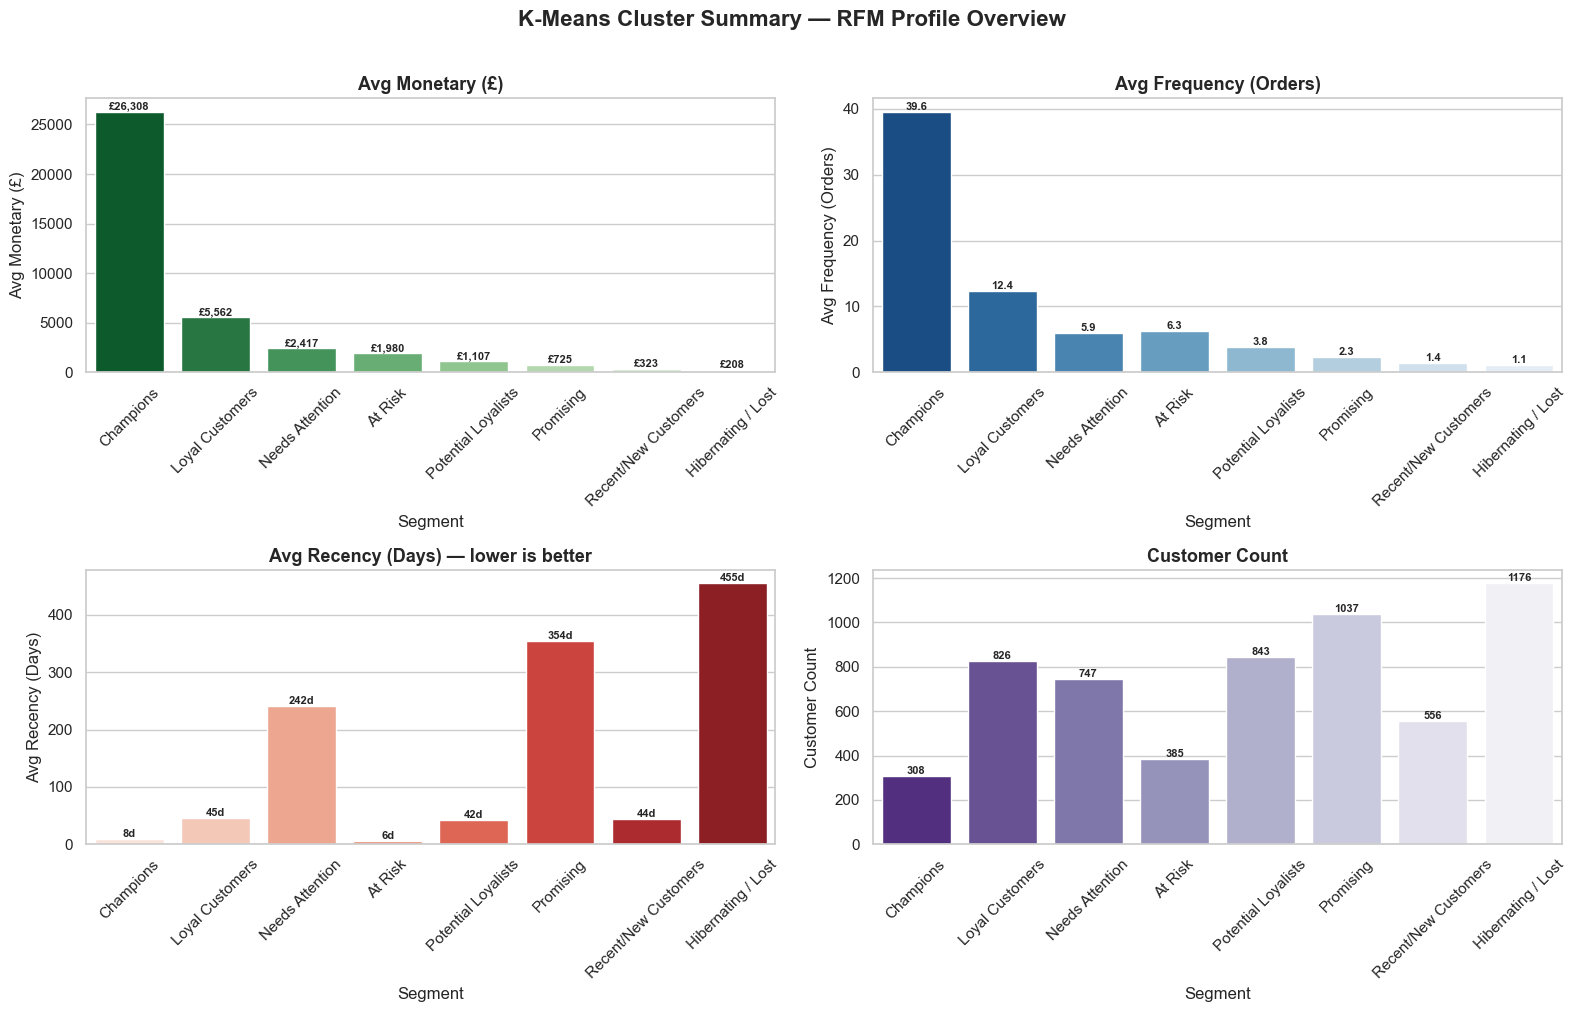

In [93]:
cluster_summary['Segment'] = cluster_summary.index.map(mapping)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1 — Avg Monetary
sns.barplot(data=cluster_summary, x='Segment', y='Avg Monetary (£)',
            palette='Greens_r', ax=axes[0, 0])
axes[0, 0].set_title('Avg Monetary (£)', fontsize=13, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'£{p.get_height():,.0f}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=8, fontweight='bold')

# 2 — Avg Frequency
sns.barplot(data=cluster_summary, x='Segment', y='Avg Frequency (Orders)',
            palette='Blues_r', ax=axes[0, 1])
axes[0, 1].set_title('Avg Frequency (Orders)', fontsize=13, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f'{p.get_height():.1f}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=8, fontweight='bold')

# 3 — Avg Recency (lower = better)
sns.barplot(data=cluster_summary, x='Segment', y='Avg Recency (Days)',
            palette='Reds', ax=axes[1, 0])
axes[1, 0].set_title('Avg Recency (Days) — lower is better', fontsize=13, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f'{p.get_height():.0f}d',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=8, fontweight='bold')

# 4 — Customer Count
sns.barplot(data=cluster_summary, x='Segment', y='Customer Count',
            palette='Purples_r', ax=axes[1, 1])
axes[1, 1].set_title('Customer Count', fontsize=13, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f'{int(p.get_height())}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=8, fontweight='bold')

fig.suptitle('K-Means Cluster Summary — RFM Profile Overview', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


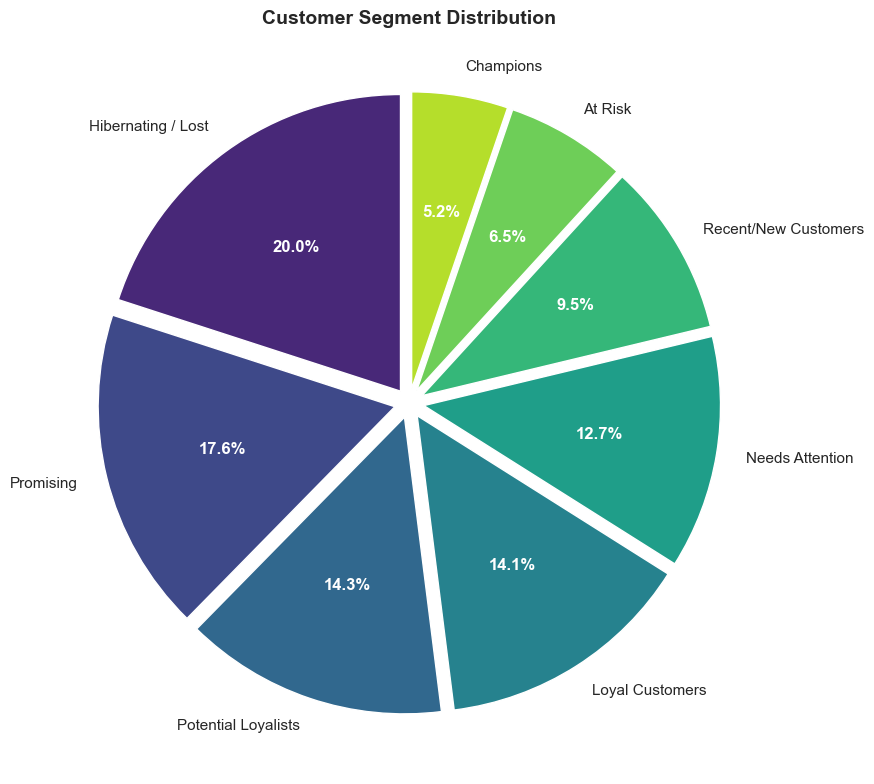

Segment Size Summary:

  Hibernating / Lost: 1176 customers (20.0%)
  Promising: 1037 customers (17.6%)
  Potential Loyalists: 843 customers (14.3%)
  Loyal Customers: 826 customers (14.1%)
  Needs Attention: 747 customers (12.7%)
  Recent/New Customers: 556 customers (9.5%)
  At Risk: 385 customers (6.5%)
  Champions: 308 customers (5.2%)


In [94]:
# --- Customer Segment Distribution Pie Chart ---
segment_counts = rfm['Segment_Name'].value_counts()

fig, ax = plt.subplots(figsize=(10, 8))
colors_pie = sns.color_palette('viridis', n_colors=optimal_k)  # ← was k_optimal

wedges, texts, autotexts = ax.pie(segment_counts.values,
                                   labels=segment_counts.index,
                                   colors=colors_pie,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   explode=[0.05] * len(segment_counts))
ax.set_title('Customer Segment Distribution', fontsize=14, fontweight='bold')

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
plt.tight_layout()
plt.show()

print("Segment Size Summary:\n")
for segment, count in segment_counts.items():
    print(f"  {segment}: {count} customers ({count/len(rfm)*100:.1f}%)")


## 6. Save Segmented Data

In [95]:
rfm.drop(columns=['Log_Recency', 'Log_Frequency', 'Log_Monetary'], inplace=True, errors='ignore')

rfm.to_csv('../data/processed/customer_segments.csv')
print("Segmented data saved to ../data/processed/customer_segments.csv")

Segmented data saved to ../data/processed/customer_segments.csv
